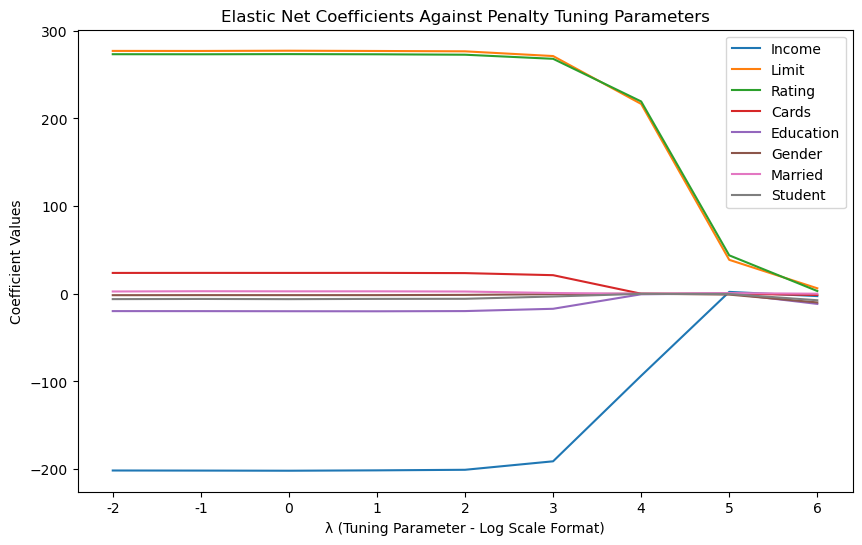

In [10]:
# Starting libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image

# Load data and set up features and target variable as in the original code
filename = "Credit_N400_p9.csv"
advertising_df = pd.read_csv(filename)
x_features_df = advertising_df.copy(deep=True)
y_features_df = x_features_df.pop("Balance")

# One-hot encode categorical variables
x_features_df = pd.get_dummies(x_features_df, columns=["Gender"], drop_first=True, dtype=int)
x_features_df = pd.get_dummies(x_features_df, columns=["Married"], drop_first=True, dtype=int)
x_features_df = pd.get_dummies(x_features_df, columns=["Student"], drop_first=True, dtype=int)

# Standardize features and target variable
y_standardized = y_features_df - y_features_df.mean()
X_standardized = (x_features_df - x_features_df.mean()) / x_features_df.std()

X = X_standardized.to_numpy()
y = y_standardized.to_numpy()

# Initialize parameters
tuning_parameters_set = [10**-2, 10**-1, 10**0, 10**1, 10**2, 10**3, 10**4, 10**5, 10**6]
k_fold = 5
observations_N = len(X)
feature_total_p = len(X_standardized.columns)
initial_beta = np.random.uniform(-1, 1, feature_total_p)

# Elastic Net specific parameter
alpha = 1  # Controls balance between L1 and L2 penalties (1 means equal balance)

# Prepare to store results
cross_validation_account_final = []
vector_parameter_beta_final = []
cross_validation_beta_account_final = []

# Loop over tuning parameters
for current_tuning_paremeter in tuning_parameters_set:
    #This is the current penalty term
    tuning_parameter = current_tuning_paremeter
    #The observations are randomly reorganized
    random_reorder = np.random.permutation(observations_N)
    #This will track the immedia cv errors as we parse through each fold in the 5 k old operation
    cross_validation_account = []
    #This will hold beta
    cross_validation_beta_account = []
    
    #This is to loop through all the folds with the current penalty value in place
    for fold in range(k_fold):
        
        #This is a reset for the beta for each iteration
        intermediary_beta = initial_beta.copy()

        #This logic is for observation placement after the random reorganization
        #A section of the observations is taken based on the current fold in play and the split size
        beg_index = fold * k_N_Splits
        end_index = (fold + 1) * k_N_Splits
        beg_to_end_indexes = np.arange(beg_index, end_index)


        #The observations for the validation part of the cross validation loop are set in place here
        validation_unit = random_reorder[beg_to_end_indexes]
        X_validation_set = X[validation_unit]
        y_validation_set = y[validation_unit]
        
        #The observations for the training part of the cross validation loop are set in place here
        X_training_set = np.delete(X, validation_unit, axis=0)
        y_training_set = np.delete(y, validation_unit, axis=0)

        
        #This loop exists for the batch gradient descent logic
        for iter_c in range(iter_loops):

            #X transposed is set for future equation use
            X_training_transposed = np.transpose(X_training_set)
            
            #The equation from assignment 2 is chunked out between the next three lines of code
            #to adjust the beta values, one small difference include in terms of arrangement
            update_pv_p1 = X_training_transposed.dot(y_training_set - X_training_set.dot(intermediary_beta))

            
            update_pv_p2 = (update_pv_p1 - (tuning_parameter * intermediary_beta))
            intermediary_beta += 2 * learning_rate_alpha * update_pv_p2
        
        #Outside of the loop the y output is predicted based on the validation set and beta provided
        y_vaidation__set_predicted = X_validation_set.dot(intermediary_beta)
        
        #a validation error score is marked based on the information
    
        validation_error = np.sum((y_validation_set - y_vaidation__set_predicted)**2) / len(y_validation_set)
        
        #The information is appended for future use
        cross_validation_account.append(validation_error)
        
        cross_validation_beta_account.append(intermediary_beta)
        #print(validation_error)
    #After the cross validation loop is done the cv error is achieved by getting the mean
    cross_validation_error = np.mean(cross_validation_account)
    #The cv error from using the current penalty value is appended to find the lowest cross validation score later
    cross_validation_account_final.append(cross_validation_error)
    #Beta is marked too
    vector_parameter_beta_final.append(intermediary_beta)
    #The mean beta from the cv loop is marked too
    cross_validation_beta_account_final.append(np.mean(cross_validation_beta_account, axis=0))
    #print(cross_validation_error)
print(cross_validation_account_final)

# Plot results
cross_validation_beta_account_final_np = np.array(cross_validation_beta_account_final)
tp_log_set = [-2, -1, 0, 1, 2, 3, 4, 5, 6]
plt.figure(figsize=(10, 6))
plt.semilogx(tuning_parameters_set, cross_validation_beta_account_final_np[:, 0], label="Income")
plt.semilogx(tuning_parameters_set, cross_validation_beta_account_final_np[:, 1], label="Limit")
plt.semilogx(tuning_parameters_set, cross_validation_beta_account_final_np[:, 2], label="Rating")
plt.semilogx(tuning_parameters_set, cross_validation_beta_account_final_np[:, 3], label="Cards")
plt.semilogx(tuning_parameters_set, cross_validation_beta_account_final_np[:, 4], label="Education")
plt.semilogx(tuning_parameters_set, cross_validation_beta_account_final_np[:, 5], label="Gender")
plt.semilogx(tuning_parameters_set, cross_validation_beta_account_final_np[:, 6], label="Married")
plt.semilogx(tuning_parameters_set, cross_validation_beta_account_final_np[:, 7], label="Student")
plt.xticks(ticks=tuning_parameters_set, labels=tp_log_set)
plt.xlabel('λ (Tuning Parameter - Log Scale Format)')
plt.ylabel('Coefficient Values')
plt.title('Elastic Net Coefficients Against Penalty Tuning Parameters')
plt.legend(loc=1)
plt.show()
